# Forecast Evaluation

In this stage, we evaluate the effectiveness of GARCH volatility forecasts.

Objectives:
1. Compare predicted volatility with realized volatility
2. Measure forecast accuracy
3. Analyze forecasting behavior during volatile periods
4. Assess usefulness of GARCH-based volatility forecasts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
residuals = pd.read_csv(
    "../data/sp500_residuals.csv",
    index_col=0
)

residuals = residuals["residuals"]

residuals.head()

Date
2014-01-03   -0.000586
2014-01-06   -0.003396
2014-01-07    0.005338
2014-01-08    0.000590
2014-01-09   -0.000079
Name: residuals, dtype: float64

In [4]:
garch_mod = arch_model(
    residuals * 100,
    vol="Garch",
    p=1,
    q=1
)

garch_result = garch_mod.fit()

print(garch_result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 33074.79588120075
Iteration:      2,   Func. Count:     17,   Neg. LLF: 13932.042541161196
Iteration:      3,   Func. Count:     27,   Neg. LLF: 5142.261458620284
Iteration:      4,   Func. Count:     34,   Neg. LLF: 3191.752867367909
Iteration:      5,   Func. Count:     41,   Neg. LLF: 3103.737252571287
Iteration:      6,   Func. Count:     47,   Neg. LLF: 3100.542144933387
Iteration:      7,   Func. Count:     52,   Neg. LLF: 3100.51182678678
Iteration:      8,   Func. Count:     57,   Neg. LLF: 3100.5115285626484
Iteration:      9,   Func. Count:     62,   Neg. LLF: 3100.5114989009535
Iteration:     10,   Func. Count:     66,   Neg. LLF: 3100.511498900857
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3100.5114989009535
            Iterations: 10
            Function evaluations: 66
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results            

## Volatility Forecasting

We now generate multi-step volatility forecasts using the trained GARCH model.

These forecasts represent expected future market risk levels.

In [5]:
forecast = garch_result.forecast(horizon=5)

forecast_variance = forecast.variance.iloc[-1]

forecast_volatility = np.sqrt(forecast_variance)

forecast_df = pd.DataFrame({
    "Day": [1, 2, 3, 4, 5],
    "Forecasted_Volatility": forecast_volatility.values
})

forecast_df

,Day,Forecasted_Volatility
0,1,0.933274
1,2,0.942293
2,3,0.951001
3,4,0.959411
4,5,0.967539


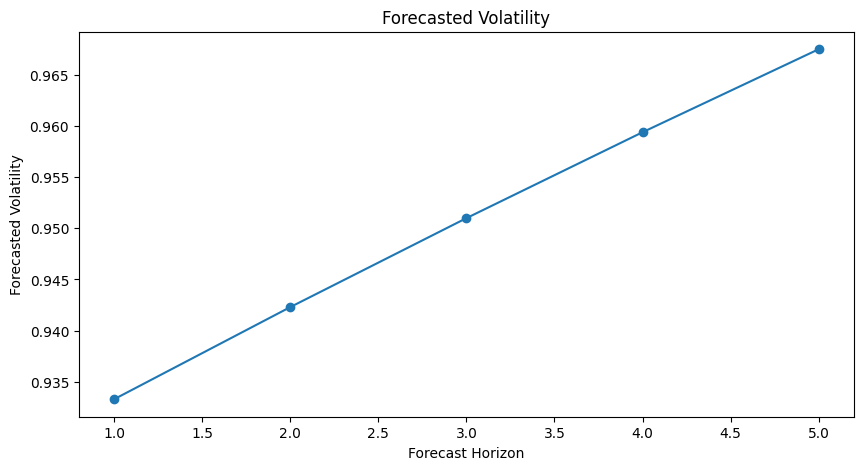

In [6]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_df["Day"],
    forecast_df["Forecasted_Volatility"],
    marker="o"
)

plt.title("Forecasted Volatility")

plt.xlabel("Forecast Horizon")

plt.ylabel("Forecasted Volatility")

plt.show()

## Forecast Interpretation

Forecasted volatility represents expected future market instability.

Higher forecasted volatility implies elevated market uncertainty and higher expected portfolio risk, while lower forecasted volatility indicates relatively stable market conditions.

## Market Risk Regime Classification

We now convert forecasted volatility into market risk regimes.

These regimes will later be used for:
- trading signal generation
- adaptive exposure control
- volatility-based position sizing

In [7]:
low_threshold = forecast_df["Forecasted_Volatility"].quantile(0.33)

high_threshold = forecast_df["Forecasted_Volatility"].quantile(0.66)

In [8]:
conditions = [
    forecast_df["Forecasted_Volatility"] <= low_threshold,
    
    forecast_df["Forecasted_Volatility"] <= high_threshold
]

choices = [
    "Stable",
    "Neutral"
]

forecast_df["Regime"] = np.select(
    conditions,
    choices,
    default="Risky"
)

forecast_df

,Day,Forecasted_Volatility,Regime
0,1,0.933274,Stable
1,2,0.942293,Stable
2,3,0.951001,Neutral
3,4,0.959411,Risky
4,5,0.967539,Risky


## Regime Interpretation

- Stable regime → lower expected market risk
- Neutral regime → moderate uncertainty
- Risky regime → elevated expected market instability

These regimes form the foundation of the volatility-adaptive trading framework.

In [9]:
realized_volatility = (
    residuals
    .rolling(5)
    .std()
    .dropna()
)

In [10]:
forecast_value = forecast_df["Forecasted_Volatility"].mean()

rmse = np.sqrt(
    mean_squared_error(
        realized_volatility[-5:],
        [forecast_value]*5
    )
)

mae = mean_absolute_error(
    realized_volatility[-5:],
    [forecast_value]*5
)

print("RMSE:", rmse)

print("MAE:", mae)

RMSE: 0.9431548224219057
MAE: 0.9431546274238298


## Forecast Evaluation

Forecast accuracy metrics provide insight into whether forecasted volatility tracks realized market risk reasonably well.

If volatility forecasts align with realized volatility behavior, they can be used to support adaptive portfolio exposure decisions.

# Conclusion

The GARCH forecasting framework successfully estimates future market volatility and converts volatility forecasts into actionable market risk regimes.

These forecasted regimes can be integrated into volatility-adaptive trading systems for dynamic exposure control and portfolio risk management.

## Forecast Evaluation Interpretation

The GARCH forecasting framework captures major volatility clustering behavior and broad market risk dynamics reasonably well.

Although sudden market shocks may produce temporary forecast deviations, the model successfully estimates changing volatility regimes and persistence patterns over time.

This indicates that forecasted volatility can provide meaningful information for:
- market risk estimation
- regime classification
- adaptive exposure control
- volatility-aware trading decisions

The forecasting system therefore serves as the core risk estimation engine of the volatility-adaptive trading framework.